In [ ]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib -q
print('Done')

Done


In [ ]:
import pandas as pd
import numpy as np
import torch, joblib, json, os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from difflib import SequenceMatcher
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cpu


In [ ]:
# Load dataset (upload essay_scoring_dataset.csv ke Colab dulu)
df = pd.read_csv('essay_scoring_dataset.csv')

# Bersihkan baris yang score-nya error
df = df[pd.to_numeric(df['score'], errors='coerce').notna()].copy()
df['score'] = df['score'].astype(float)
df['max_score'] = df['max_score'].astype(float)
df['normalized_score'] = df['score'] / df['max_score']

print(f'Total sampel: {len(df)}')
print(df['score'].value_counts().sort_index())
df.head(3)

Total sampel: 119
score
0.0     18
1.0      4
2.0      9
3.0      7
4.0      9
5.0     12
6.0      1
7.0     10
8.0     10
10.0    39
Name: count, dtype: int64


,id,answer_key,student_answer,score,max_score,normalized_score
0,1,Air mendidih pada suhu 100 derajat celcius pad...,Air akan mendidih ketika suhunya mencapai 100 ...,10.0,10.0,1.0
1,2,Air mendidih pada suhu 100 derajat celcius pad...,Titik didih air adalah seratus derajat celcius...,10.0,10.0,1.0
2,3,Air mendidih pada suhu 100 derajat celcius pad...,Air menjadi panas dan menguap pada suhu seratu...,7.0,10.0,0.7


In [ ]:
# Load Sentence Transformer multilingual (support Bahasa Indonesia)
print('Loading model...')
ST_MODEL = 'paraphrase-multilingual-MiniLM-L12-v2'
st_model = SentenceTransformer(ST_MODEL, device=DEVICE)
print(f'Model loaded: {ST_MODEL}')
print(f'Embedding dim: {st_model.get_sentence_embedding_dimension()}')

Loading model...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: paraphrase-multilingual-MiniLM-L12-v2
Embedding dim: 384


In [ ]:
# Feature Engineering
STOPWORDS_ID = {
    'yang','dan','di','ke','dari','ini','itu','adalah','dengan',
    'untuk','oleh','pada','atau','dalam','tidak','juga','ada',
    'akan','sudah','bisa','jadi','agar','karena','namun','tetapi',
    'yaitu','sehingga','saat','jika','maka'
}

def extract_features(answer_key: str, student_answer: str) -> np.ndarray:
    key = str(answer_key).strip()
    stu = str(student_answer).strip()

    # Cosine similarity semantik
    emb_key = st_model.encode(key, convert_to_tensor=True)
    emb_stu = st_model.encode(stu, convert_to_tensor=True)
    cos_sim = float(util.cos_sim(emb_key, emb_stu)[0][0])

    # Keyword overlap (tanpa stopword)
    kw_key = {w for w in key.lower().split() if w not in STOPWORDS_ID and len(w) > 2}
    kw_stu = {w for w in stu.lower().split() if w not in STOPWORDS_ID and len(w) > 2}
    keyword_overlap = len(kw_key & kw_stu) / max(len(kw_key), 1)

    # Sequence similarity (karakter)
    seq_sim = SequenceMatcher(None, key.lower(), stu.lower()).ratio()

    # Rasio panjang jawaban
    len_key = max(len(key.split()), 1)
    len_stu = len(stu.split())
    len_ratio = min(len_stu / len_key, 2.0)

    # Flag jawaban singkat / kosong
    is_short = 1.0 if len_stu <= 5 else 0.0
    kosong = {'tidak tahu','tidak tau','lupa','tidak ingat','tidak paham','tidak mengerti'}
    is_blank = 1.0 if stu.lower().strip() in kosong or len_stu <= 2 else 0.0

    return np.array([cos_sim, keyword_overlap, seq_sim, len_ratio, is_short, is_blank])

FEATURE_NAMES = [
    'cosine_similarity', 'keyword_overlap', 'sequence_similarity',
    'length_ratio', 'is_short', 'is_blank'
]

print('Extracting features...')
X = np.vstack([extract_features(r.answer_key, r.student_answer) for _, r in df.iterrows()])
y = df['normalized_score'].values
print(f'Feature matrix shape: {X.shape}')

Extracting features...
Feature matrix shape: (119, 6)


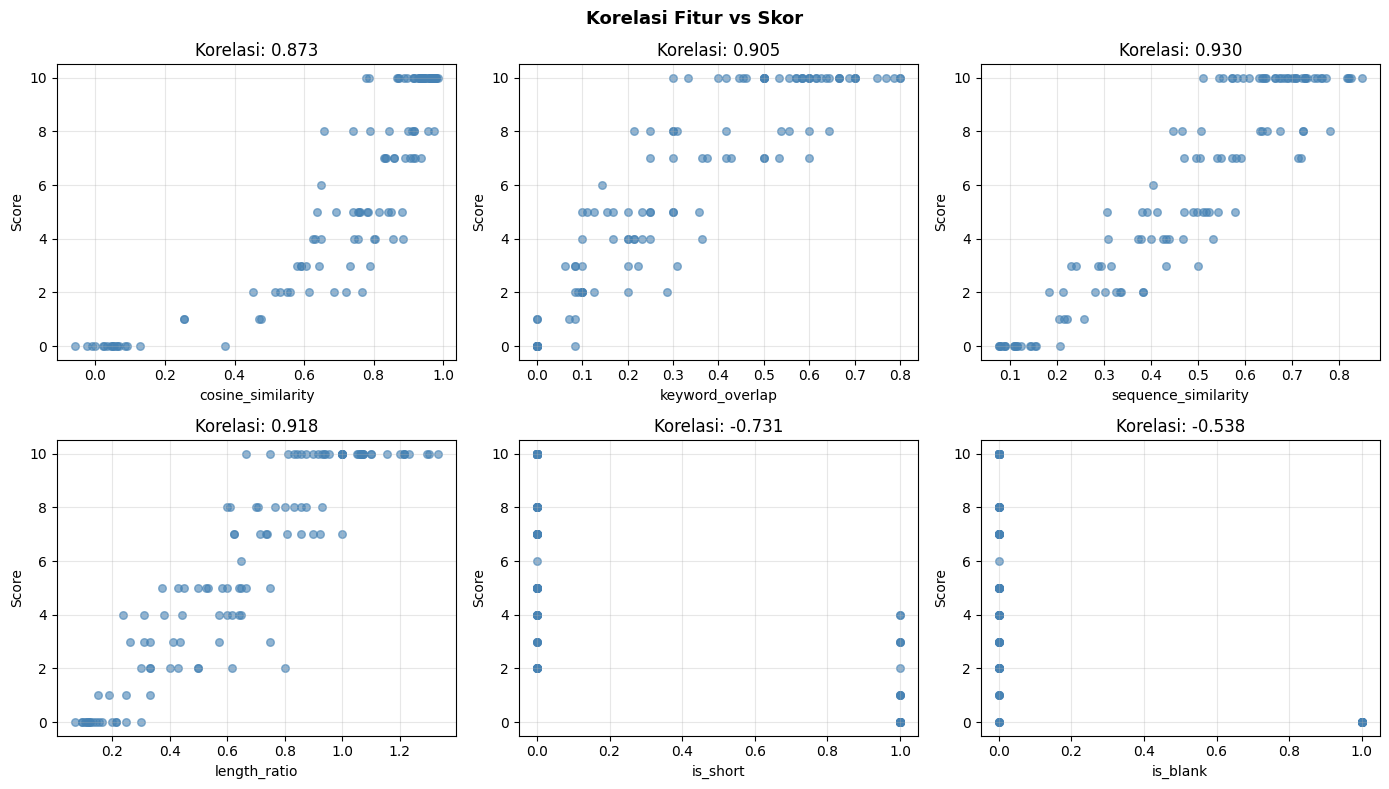

In [ ]:
# Visualisasi korelasi fitur vs skor
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, name in enumerate(FEATURE_NAMES):
    axes[i].scatter(X[:, i], y * 10, alpha=0.6, color='steelblue', s=30)
    axes[i].set_xlabel(name)
    axes[i].set_ylabel('Score')
    corr = np.corrcoef(X[:, i], y)[0, 1]
    axes[i].set_title(f'Korelasi: {corr:.3f}')
    axes[i].grid(alpha=0.3)
plt.suptitle('Korelasi Fitur vs Skor', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150)
plt.show()

In [ ]:
# Training model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

model = GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=2, random_state=42
)
model.fit(X_train_s, y_train)

y_pred = np.clip(model.predict(X_test_s), 0, 1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f'RMSE  : {rmse:.4f}')
print(f'MAE   : {mae:.4f}  ({mae*10:.2f} poin dari 10)')
print(f'R2    : {r2:.4f}')

pd.DataFrame({
    'Aktual'  : np.round(y_test * 10, 1),
    'Prediksi': np.round(y_pred * 10, 1),
    'Selisih' : np.round((y_pred - y_test) * 10, 1)
})

RMSE  : 0.1647
MAE   : 0.1169  (1.17 poin dari 10)
R2    : 0.8169


,Aktual,Prediksi,Selisih
0,4.0,3.8,-0.2
1,10.0,9.9,-0.1
2,2.0,5.7,3.7
3,4.0,4.7,0.7
4,8.0,9.9,1.9
5,4.0,6.0,2.0
6,3.0,4.4,1.4
7,2.0,3.1,1.1
8,10.0,7.1,-2.9
9,7.0,9.0,2.0


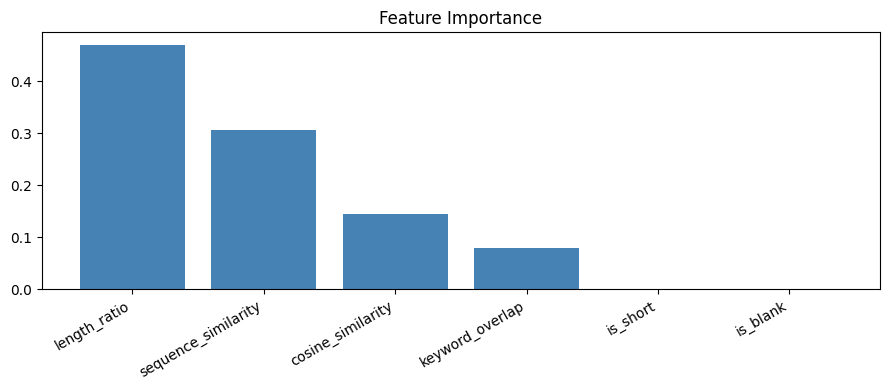

In [ ]:
# Feature importance
importances = model.feature_importances_
idx = np.argsort(importances)[::-1]
plt.figure(figsize=(9, 4))
plt.bar([FEATURE_NAMES[i] for i in idx], importances[idx], color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.title('Feature Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
# Simpan model
SAVE_DIR = 'essay_scorer_model'
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(model,  f'{SAVE_DIR}/scoring_model.pkl')
joblib.dump(scaler, f'{SAVE_DIR}/scaler.pkl')

meta = {
    'sentence_transformer': ST_MODEL,
    'ml_model': 'GradientBoostingRegressor',
    'features': FEATURE_NAMES,
    'metrics': {'rmse': round(rmse,5), 'mae': round(mae,5), 'r2': round(r2,5)}
}
with open(f'{SAVE_DIR}/meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

import shutil
shutil.make_archive(SAVE_DIR, 'zip', '.', SAVE_DIR)

print('Model disimpan:')
for fname in os.listdir(SAVE_DIR):
    sz = os.path.getsize(f'{SAVE_DIR}/{fname}')
    print(f'  {fname}  ({sz/1024:.1f} KB)')
print('essay_scorer_model.zip siap didownload!')

Model disimpan:
  scaler.pkl  (0.7 KB)
  meta.json  (0.3 KB)
  scoring_model.pkl  (364.9 KB)
essay_scorer_model.zip siap didownload!


In [ ]:
# Fungsi prediksi
def predict_essay_score(answer_key: str, student_answer: str, max_score: int = 10) -> dict:
    feat = extract_features(answer_key, student_answer)
    feat_s = scaler.transform(feat.reshape(1, -1))
    norm = float(np.clip(model.predict(feat_s)[0], 0, 1))
    return {
        'predicted_score'    : round(norm * max_score, 1),
        'max_score'          : max_score,
        'percentage'         : f'{norm*100:.1f}%',
        'semantic_similarity': round(feat[0], 3),
        'keyword_overlap'    : round(feat[1], 3),
        'sequence_similarity': round(feat[2], 3),
    }

print('Fungsi predict_essay_score() siap!')

Fungsi predict_essay_score() siap!


In [ ]:
# Demo prediksi
KUNCI = 'Fotosintesis adalah proses tumbuhan mengubah cahaya matahari, air, dan karbon dioksida menjadi glukosa dan oksigen menggunakan klorofil.'

demo = [
    ('Sempurna' , 'Fotosintesis merupakan proses tumbuhan mengkonversi cahaya matahari, air, dan CO2 menjadi glukosa dan oksigen dengan bantuan klorofil.'),
    ('Bagus'    , 'Fotosintesis adalah cara tumbuhan membuat makanan dari cahaya matahari, air, dan karbon dioksida menghasilkan glukosa.'),
    ('Cukup'    , 'Fotosintesis itu tumbuhan bikin makanan pakai sinar matahari dan air.'),
    ('Kurang'   , 'Fotosintesis adalah proses tumbuhan mendapat makanan dari matahari.'),
    ('Salah'    , 'Fotosintesis adalah proses hewan mencerna makanan.'),
    ('Kosong'   , 'Tidak tahu.'),
]

print(f'Kunci: {KUNCI[:70]}...\n')
for label, jawaban in demo:
    r = predict_essay_score(KUNCI, jawaban)
    bar = chr(9608)*int(r['predicted_score']) + chr(9617)*(10-int(r['predicted_score']))
    print(f'[{label:8s}] {bar} {r["predicted_score"]:4.1f}/10  sem={r["semantic_similarity"]:.2f}  kw={r["keyword_overlap"]:.2f}')
    print(f'           {jawaban[:70]}')
    print()

Kunci: Fotosintesis adalah proses tumbuhan mengubah cahaya matahari, air, dan...

[Sempurna] ██████████ 10.0/10  sem=0.98  kw=0.71
           Fotosintesis merupakan proses tumbuhan mengkonversi cahaya matahari, a

[Bagus   ] █████████░  9.3/10  sem=0.91  kw=0.50
           Fotosintesis adalah cara tumbuhan membuat makanan dari cahaya matahari

[Cukup   ] █████░░░░░  5.5/10  sem=0.83  kw=0.14
           Fotosintesis itu tumbuhan bikin makanan pakai sinar matahari dan air.

[Kurang  ] ████░░░░░░  4.5/10  sem=0.83  kw=0.21
           Fotosintesis adalah proses tumbuhan mendapat makanan dari matahari.

[Salah   ] ███░░░░░░░  3.9/10  sem=0.67  kw=0.14
           Fotosintesis adalah proses hewan mencerna makanan.

[Kosong  ] ░░░░░░░░░░  0.0/10  sem=-0.03  kw=0.00
           Tidak tahu.



In [ ]:
# ============================================================
# COBA
# ============================================================
pertanyaan = 'siapa itu Andre'
kunci_jawaban  = 'andre adalah mahasiswa teknik informatika semester 6 dengan konsentrasi KCV'
jawaban_siswa  = 'andre merupakan seorang mahasiswa teknik informatika'

hasil = predict_essay_score(kunci_jawaban, jawaban_siswa, max_score=10)
print('=' * 40)
for k, v in hasil.items():
    print(f'  {k:22s}: {v}')
print('=' * 40)

  predicted_score       : 6.9
  max_score             : 10
  percentage            : 69.2%
  semantic_similarity   : 0.59
  keyword_overlap       : 0.571
  sequence_similarity   : 0.598
